# ROI de frota vs. taxa de juros do financiamento

Três perguntas sobre os 3 caminhões (dados sintéticos, `src/generate_data.py`):

1. Qual o resultado real de cada caminhão, descontando a parcela do financiamento?
2. Em quantos meses ele se paga?
3. O que muda se a taxa de juros fosse outra?

Lê só de `gold.db`, a camada final do pipeline (`bronze -> silver -> gold`).

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = Path("..") / "gold.db"
conn = sqlite3.connect(DB_PATH)

veiculos = pd.read_sql("SELECT * FROM gold_dim_veiculo", conn)
resultado_mensal = pd.read_sql("SELECT * FROM gold_resultado_mensal", conn)

veiculos

,veiculo_id,placa,modelo,valor_veiculo,valor_entrada,valor_financiado,taxa_juros_anual,prazo_meses
0,1,FIC-1A23,Caminhao 0km c/ implemento,465000.0,93000.0,372000.0,0.1336,60
1,2,FIC-2B45,Caminhao 0km c/ implemento,480000.0,96000.0,384000.0,0.1336,60
2,3,FIC-3C67,Caminhao 0km c/ implemento,470000.0,94000.0,376000.0,0.1336,60


## 1. Resultado real de cada caminhão

`resultado_operacional` parece saudável. `resultado_liquido` (depois da parcela) conta outra história.

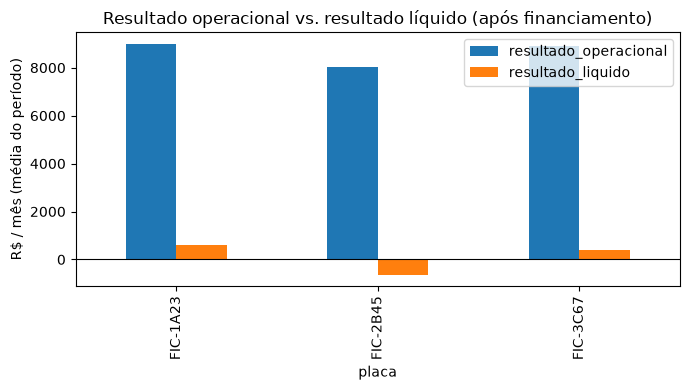

,resultado_operacional,resultado_liquido
placa,,
FIC-1A23,8994.16,604.93
FIC-2B45,8018.39,-641.46
FIC-3C67,8888.02,408.59


In [2]:
resumo = (
    resultado_mensal.merge(veiculos, on="veiculo_id")
    .groupby("placa")[["resultado_operacional", "resultado_liquido"]]
    .mean()
    .round(2)
)

ax = resumo.plot(kind="bar", figsize=(7, 4))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("R$ / mês (média do período)")
ax.set_title("Resultado operacional vs. resultado líquido (após financiamento)")
plt.tight_layout()
plt.show()

resumo

### DSCR: dá pra sustentar mais dívida?

Índice de cobertura do serviço da dívida (resultado operacional / parcela). É o número que banco olha pra decidir se aprova crédito novo. Abaixo de 1,0 o caminhão nem cobre a própria parcela; entre 1,0 e 1,3 cobre, mas sem folga pra imprevisto; acima de 1,3 é o patamar geralmente considerado seguro pra sustentar mais alavancagem.

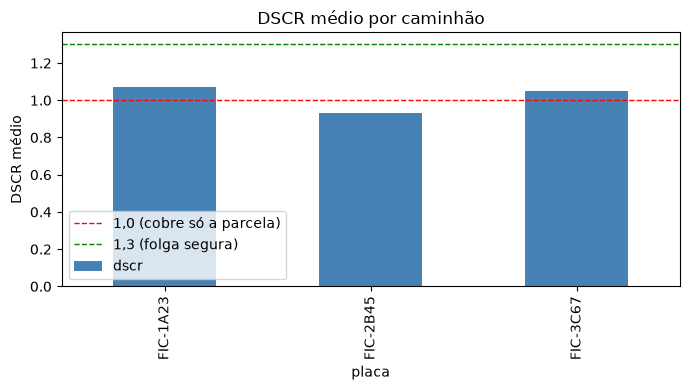

placa
FIC-1A23    1.07
FIC-2B45    0.93
FIC-3C67    1.05
Name: dscr, dtype: float64

In [3]:
dscr_medio = (
    resultado_mensal.merge(veiculos, on="veiculo_id")
    .groupby("placa")["dscr"]
    .mean()
    .round(2)
)

ax = dscr_medio.plot(kind="bar", figsize=(7, 4), color="steelblue")
ax.axhline(1.0, color="red", linewidth=1, linestyle="--", label="1,0 (cobre só a parcela)")
ax.axhline(1.3, color="green", linewidth=1, linestyle="--", label="1,3 (folga segura)")
ax.set_ylabel("DSCR médio")
ax.set_title("DSCR médio por caminhão")
ax.legend()
plt.tight_layout()
plt.show()

dscr_medio

## 2. Payback acumulado

Resultado líquido acumulado mês a mês, partindo de -entrada. Cruzou o zero, pagou.

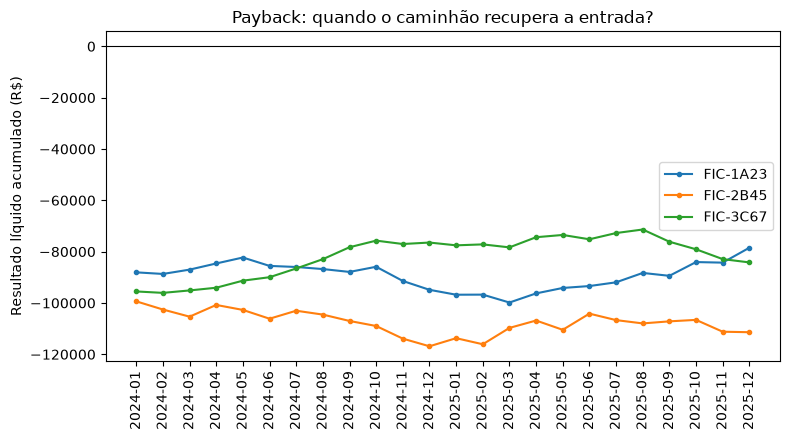

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for placa, grupo in resultado_mensal.merge(veiculos, on="veiculo_id").groupby("placa"):
    grupo = grupo.sort_values("mes_referencia")
    ax.plot(grupo["mes_referencia"], grupo["resultado_liquido_acumulado"], marker="o", markersize=3, label=placa)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Resultado líquido acumulado (R$)")
ax.set_title("Payback: quando o caminhão recupera a entrada?")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## 3. E se a taxa de juros fosse outra?

O resultado operacional não muda com a taxa, quem muda é a parcela. Simulando de 8% a 22% a.a. (a real é 13,36%), com resultado operacional médio constante pelos 60 meses.

In [5]:
import numpy as np

TAXA_REAL = 0.1336
TAXAS_SIMULADAS = np.arange(0.08, 0.225, 0.005)

def parcela_price(valor_financiado, taxa_anual, prazo_meses=60):
    i = (1 + taxa_anual) ** (1 / 12) - 1
    return valor_financiado * i / (1 - (1 + i) ** -prazo_meses)

operacional_medio = resultado_mensal.groupby("veiculo_id")["resultado_operacional"].mean()

simulacao = []
for _, v in veiculos.iterrows():
    veiculo_id = v["veiculo_id"]
    for taxa in TAXAS_SIMULADAS:
        parcela = parcela_price(v["valor_financiado"], taxa, v["prazo_meses"])
        resultado_liquido_sim = operacional_medio[veiculo_id] - parcela
        if resultado_liquido_sim > 0:
            payback_meses = v["valor_entrada"] / resultado_liquido_sim
            payback_meses = min(payback_meses, v["prazo_meses"])
        else:
            payback_meses = np.nan  # nao se paga dentro do prazo do financiamento
        simulacao.append({
            "placa": v["placa"], "taxa_juros_anual": round(taxa, 4),
            "parcela": round(parcela, 2), "resultado_liquido_simulado": round(resultado_liquido_sim, 2),
            "payback_meses": payback_meses,
        })

simulacao = pd.DataFrame(simulacao)
simulacao.head()

,placa,taxa_juros_anual,parcela,resultado_liquido_simulado,payback_meses
0,FIC-1A23,0.080,7493.22,1500.95,60.0
1,FIC-1A23,0.085,7575.94,1418.22,60.0
2,FIC-1A23,0.090,7658.85,1335.31,60.0
3,FIC-1A23,0.095,7741.95,1252.21,60.0
4,FIC-1A23,0.100,7825.24,1168.93,60.0


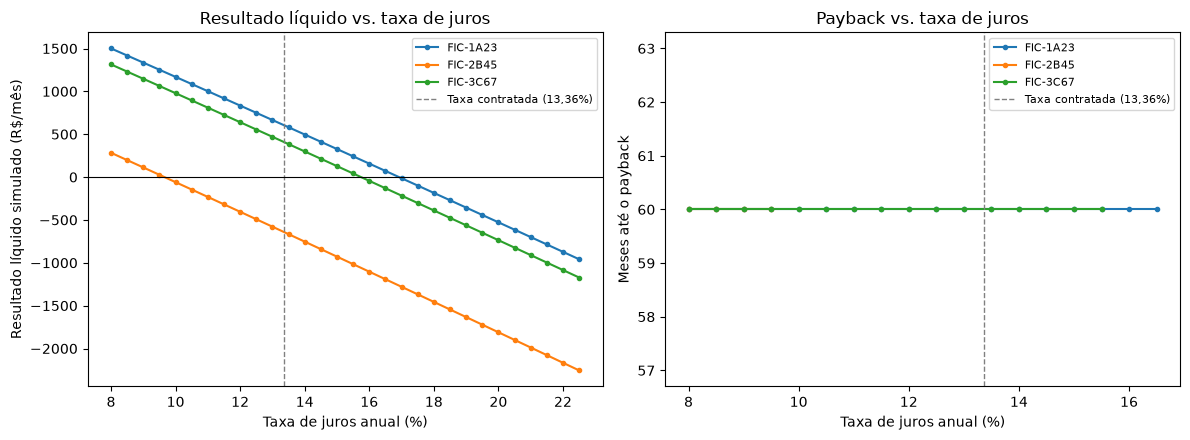

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for placa, grupo in simulacao.groupby("placa"):
    ax1.plot(grupo["taxa_juros_anual"] * 100, grupo["resultado_liquido_simulado"], marker="o", markersize=3, label=placa)
    ax2.plot(grupo["taxa_juros_anual"] * 100, grupo["payback_meses"], marker="o", markersize=3, label=placa)

for ax in (ax1, ax2):
    ax.axvline(TAXA_REAL * 100, color="gray", linestyle="--", linewidth=1, label="Taxa contratada (13,36%)")
    ax.set_xlabel("Taxa de juros anual (%)")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Resultado líquido simulado (R$/mês)")
ax1.set_title("Resultado líquido vs. taxa de juros")
ax1.legend(fontsize=8)

ax2.set_ylabel("Meses até o payback")
ax2.set_title("Payback vs. taxa de juros")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Composição dos custos

Onde o dinheiro vai, somando os 3 caminhões.

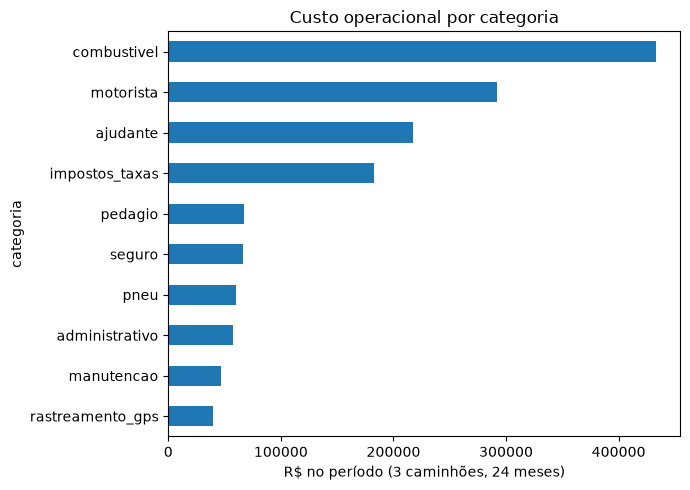

In [7]:
custos = pd.read_sql("SELECT categoria, SUM(valor) as total FROM gold_custo_categoria_mensal GROUP BY categoria ORDER BY total DESC", conn)

ax = custos.plot(kind="barh", x="categoria", y="total", figsize=(7, 5), legend=False)
ax.invert_yaxis()
ax.set_xlabel("R$ no período (3 caminhões, 24 meses)")
ax.set_title("Custo operacional por categoria")
plt.tight_layout()
plt.show()

## Conclusões

Isolado, o resultado operacional dos 3 caminhões parece saudável. Depois de descontar a parcela (Price, 13,36% a.a., 60 meses, ~R$ 470 mil/caminhão), a margem real fica apertada (um deles opera no vermelho em média) e nenhum recupera a entrada em 24 meses.

A simulação mostra o motivo pra isso importar: poucos pontos de taxa mudam o payback de "alguns anos" pra "nunca dentro do prazo". Decisão de expansão de frota não dá pra avaliar só pelo operacional, o custo do capital pesa tanto quanto.